# 2. Augmentation ablation for segmentation

The segmentation model was trained 5 times under each of four augmentation settings and every model was evaluated on the **external FLIR test set**. Validation scores are measured on held-out images from the training distribution, so the gap between validation and test F1 shows how well each setting generalises to a new acquisition setup.

| Setting | Transforms |
|---|---|
| No augmentation | light global augmentation only |
| Photometric degradation | noise, blur, contrast/gamma, inversion, down-scaling |
| Geometric / structural | flips, affine & elastic warps, crops, cut-out |
| Full | geometric followed by photometric |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS = Path("../results")
FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#8a8a85",
        "axes.labelcolor": "#2b2b29",
        "axes.titleweight": "semibold",
        "xtick.color": "#5c5c58",
        "ytick.color": "#5c5c58",
        "axes.grid": True,
        "axes.grid.axis": "y",
        "axes.axisbelow": True,
        "grid.color": "#e4e4e0",
        "grid.linewidth": 0.8,
        "legend.frameon": False,
    }
)
BLUE, ORANGE = "#2a78d6", "#eb6834"

In [2]:
df = pd.read_csv(RESULTS / "augmentation_ablation.csv")
names = {
    "no_transform": "No augmentation",
    "fotometric_degradation_transform": "Photometric",
    "geometric_structural_transform": "Geometric",
    "full_transform": "Full",
}
df["setting"] = df["experiment"].map(names)
cols = ["val_f1", "test_f1", "test_iou", "test_recall (sensitivity)", "test_auc"]
summary = df.groupby("setting")[cols].agg(["mean", "std"]).round(3)
summary = summary.loc[list(names.values())]
summary

val_f1        test_f1        test_iou         \
                  mean    std    mean    std     mean    std   
setting                                                        
No augmentation  0.837  0.153   0.461  0.210    0.316  0.156   
Photometric      0.910  0.009   0.414  0.279    0.291  0.209   
Geometric        0.889  0.030   0.726  0.036    0.571  0.044   
Full             0.903  0.016   0.702  0.055    0.543  0.065   

                test_recall (sensitivity)        test_auc         
                                     mean    std     mean    std  
setting                                                           
No augmentation                     0.331  0.167    0.663  0.082  
Photometric                         0.298  0.215    0.648  0.106  
Geometric                           0.775  0.107    0.862  0.043  
Full                                0.719  0.090    0.836  0.040

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


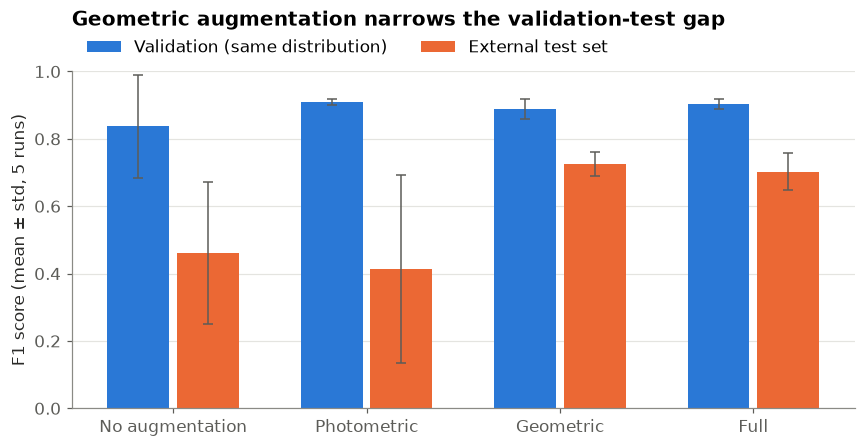

In [3]:
import numpy as np

mean = df.groupby("setting")[["val_f1", "test_f1"]].mean().loc[list(names.values())]
std = df.groupby("setting")[["val_f1", "test_f1"]].std().loc[list(names.values())]

x = np.arange(len(mean))
width = 0.36
fig, ax = plt.subplots(figsize=(8, 4.2))
for offset, col, color, label in [(-width / 2, "val_f1", BLUE, "Validation (same distribution)"),
                                  (width / 2, "test_f1", ORANGE, "External test set")]:
    ax.bar(x + offset, mean[col], width - 0.04, yerr=std[col], color=color, label=label,
           error_kw={"elinewidth": 1, "capsize": 3, "ecolor": "#5c5c58"})
ax.set_xticks(x, mean.index)
ax.set_ylabel("F1 score (mean ± std, 5 runs)")
ax.set_ylim(0, 1)
ax.set_title("Geometric augmentation narrows the validation-test gap", loc="left", pad=30)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncols=2)
fig.tight_layout()
fig.savefig(FIGURES / "augmentation_ablation.png", dpi=200)

**Takeaways**

- Without augmentation, or with photometric changes alone, the model scores well on validation but drops to a test F1 below 0.5.
- Geometric/structural augmentation is what drives generalisation: test F1 rises to about 0.73 and becomes much more stable across runs.
- Adding photometric degradation on top of geometric (Full) gives no further gain.